# Voxter: Theory-Synchronized Visuomotor Policy

This notebook presents the Voxter real-time visuomotor policy for Geometry Dash in a theory-first, artifact-auditable form. It follows the same philosophy as the midterm solution notebooks: start from the mathematical contract, then inspect the dataset, then load and interpret the trained artifact, and only then discuss empirical evidence.

The local source of truth is:

- `data/raw/phase-a-baseline-20260527-0001` and the Stage 1 datasets in `data/datasets/`;
- the exported ONNX policy `models/voxter/voxter.onnx` and its metadata `models/voxter/voxter.onnx.json`;
- the local benchmark `models/voxter/benchmark-check.json`;
- the live run summary `models/voxter/voxter_live_summary.json`;
- the recorded showcase `assets/showcase.mp4`.

The goal is not to retrain the model here. The goal is to make the modeling choice, dataset contract, training evidence, and exported behavior auditable from the artifacts already produced by the Voxter pipeline.

## 1. Control problem and notation

Geometry Dash exposes only rendered frames to the agent. At each control tick $t$ the agent must decide whether the jump input is held or released during the next interval. Let

$$
\mathcal A = \{0,1\},
$$

where $a_t=1$ means the jump button is held and $a_t=0$ means it is released. The action space is the **held state**, not a press/release event.

The capture pipeline produces a raw image $I_t \in \{0,\dots,255\}^{H_0 \times W_0 \times 3}$, which is preprocessed into a single grayscale observation

$$
o_t = P_{\text{pre}}(I_t) \in \{0,\dots,255\}^{H \times W}.
$$

A short history of observations is stacked into a 3-D tensor

$$
x_t = (o_{t-K+1},\dots,o_t) \in \{0,\dots,255\}^{K \times H \times W}.
$$

Because velocity, gravity flips, and portal effects are hidden, the agent maintains a recurrent belief state. The augmented state at tick $t$ is

$$
s_t^{\text{aug}} = (x_t, a_{t-1}, h_{t-1}).
$$

The policy is parameterized by $\theta$ and factorizes as

$$
h_t = R_\phi(h_{t-1}, [E_\theta(x_t), a_{t-1}]), \qquad
\pi_\theta(a_t=1 \mid h_t) = \sigma(W_h h_t + b_h),
$$

where $E_\theta$ is the visual encoder, $R_\phi$ is the GRU, and $[\cdot,\cdot]$ denotes concatenation. The model also emits auxiliary transition logits

$$
\ell_{\text{press},t} = W_p h_t + b_p, \qquad
\ell_{\text{release},t} = W_r h_t + b_r,
$$

but these are decoding aids; the underlying action space remains $\mathcal A$.

## 2. Dataset contract and causal alignment

The raw acquisition writes three JSONL manifest streams plus a summary:

- `frames.jsonl`: one row per captured frame with frame index, timestamp, frame path, and per-frame held state;
- `input_events.jsonl`: raw Linux key press/release events used to reconstruct the held-state timeline;
- `terminal_events.jsonl`: manual death/reset/completion markers;
- `capture_summary.json`: run-level metadata.

The **causal alignment rule** defines the supervised target for frame $t$ as the logged held state at index $t+\delta_{\text{sys}}$:

$$
y_t = a^{\text{log}}_{t+\delta_{\text{sys}}}.
$$

The current checkpoint uses $\delta_{\text{sys}}=0$. Samples whose aligned label falls outside the run are discarded.

Preprocessing is governed by named contracts:

| Contract | Responsibility |
|---|---|
| `observation-v1` | RGB/raw frame $\rightarrow$ grayscale $H\times W$ tensor |
| `frame-stack-v1` | concatenate $K$ observations into $K\times H\times W$; oldest repeated at run start |
| `aligned-manifest-v1` | align frame indices with $\delta_{\text{sys}}$ |
| `stage1-manifest-v1` | materialized sample rows with paths, labels, and schema versions |
| `stage1-dataset-summary-v1` | dataset-level counts and parameters |

Terminal cleaning discards a short window around each death (`death_tail_s`) and after each reset (`reset_skip_s`), so the policy does not learn from ambiguous post-death frames.

## 3. Imports and repository paths

In [4]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = (NOTEBOOK_DIR / "..").resolve()

# Make the local `voxter` package importable even when it is not installed
# in the active kernel (e.g. a fresh venv that only has the notebook deps).
sys.path.insert(0, str(PROJECT_ROOT / "src"))

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
DATASETS_DIR = DATA_DIR / "datasets"
MODELS_DIR = PROJECT_ROOT / "models" / "voxter"
ASSETS_DIR = PROJECT_ROOT / "assets"

paths = {
    "first_raw_run": sorted(RAW_DIR.iterdir())[0],
    "stage1_datasets": DATASETS_DIR,
    "onnx_model": MODELS_DIR / "voxter.onnx",
    "onnx_metadata": MODELS_DIR / "voxter.onnx.json",
    "benchmark": MODELS_DIR / "benchmark-check.json",
    "live_summary": MODELS_DIR / "voxter_live_summary.json",
    "showcase_video": ASSETS_DIR / "showcase.mp4",
}

for name, path in paths.items():
    print(f"{name:24s}: {path}  exists={path.exists()}")

first_raw_run           : /home/mitin/code/ml-theory/project/data/raw/phase-a-baseline-20260527-0001  exists=True
stage1_datasets         : /home/mitin/code/ml-theory/project/data/datasets  exists=True
onnx_model              : /home/mitin/code/ml-theory/project/models/voxter/voxter.onnx  exists=True
onnx_metadata           : /home/mitin/code/ml-theory/project/models/voxter/voxter.onnx.json  exists=True
benchmark               : /home/mitin/code/ml-theory/project/models/voxter/benchmark-check.json  exists=True
live_summary            : /home/mitin/code/ml-theory/project/models/voxter/voxter_live_summary.json  exists=True
showcase_video          : /home/mitin/code/ml-theory/project/assets/showcase.mp4  exists=True


## 4. Raw acquisition structure

In [5]:
first_raw_run = paths["first_raw_run"]

with (first_raw_run / "capture_summary.json").open() as f:
    raw_summary = json.load(f)

dataset_candidates = sorted(
    d for d in DATASETS_DIR.iterdir()
    if d.is_dir() and first_raw_run.name in d.name
)
stage1_dir = next(
    (d for d in dataset_candidates if "k8-320x180" in d.name),
    dataset_candidates[0],
)

with (stage1_dir / "dataset_summary.json").open() as f:
    dataset_summary = json.load(f)

print("First raw acquisition:", first_raw_run.name)
print(f"  frames:             {raw_summary['frame_count']}")
print(f"  input events:       {raw_summary['input_event_count']}")
print(f"  terminal events:    {raw_summary['terminal_event_count']}")
print(f"  effective Hz:       {raw_summary['effective_hz']:.2f}")
print(f"  held frames:        {raw_summary['held_frame_count']}")
print(f"  released frames:    {raw_summary['released_frame_count']}")
print()
print("Matching Stage 1 dataset:", stage1_dir.name)
print(f"  samples:            {dataset_summary['sample_count']}")
print(f"  held:               {dataset_summary['held_count']}")
print(f"  released:           {dataset_summary['released_count']}")
print(f"  observation:        {dataset_summary['observation_width']}x{dataset_summary['observation_height']} {dataset_summary['observation_dtype']}")
print(f"  frame stack:        K={dataset_summary['frame_stack_length']}, layout={dataset_summary['frame_stack_layout']}")
print(f"  delta_sys:          {dataset_summary['delta_sys']}")
print(f"  death_tail_s:       {dataset_summary['death_tail_s']}")
print(f"  reset_skip_s:       {dataset_summary['reset_skip_s']}")

First raw acquisition: phase-a-baseline-20260527-0001
  frames:             3583
  input events:       272
  terminal events:    1
  effective Hz:       59.72
  held frames:        1178
  released frames:    2405

Matching Stage 1 dataset: phase-a-baseline-20260527-0001-stage1-k8-320x180
  samples:            3481
  held:               1169
  released:           2312
  observation:        320x180 uint8
  frame stack:        K=8, layout=khw
  delta_sys:          0
  death_tail_s:       0.35
  reset_skip_s:       1.5


## 5. Raw held-state timeline

Raw input events: 272
Timeline entries: 272


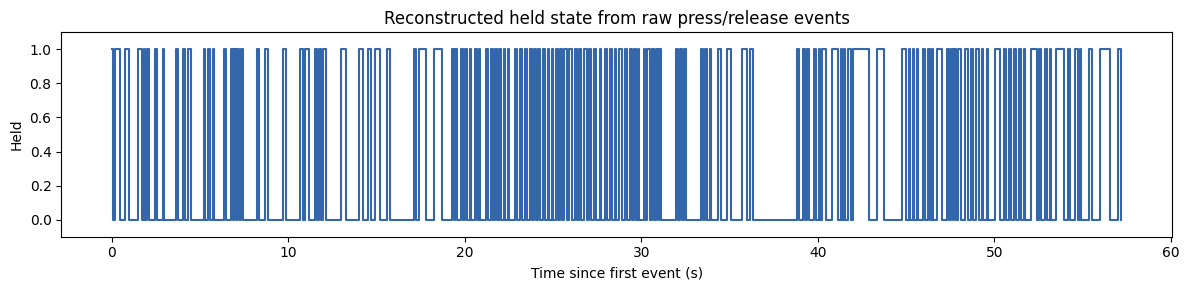

In [6]:
from voxter.capture.events import InputEventKind, RawInputEvent, reconstruct_held_state
from voxter.contracts import ActionState

with (first_raw_run / "input_events.jsonl").open() as f:
    input_events = [json.loads(line) for line in f]

events = [
    RawInputEvent(
        run_id=evt["run_id"],
        attempt_id=evt.get("attempt_id"),
        timestamp=evt["timestamp"],
        device=evt["device"],
        key_code=evt["key_code"],
        kind=InputEventKind(evt["kind"]),
        action=ActionState(evt["action"]),
    )
    for evt in input_events
]

timeline = reconstruct_held_state(events)
print(f"Raw input events: {len(events)}")
print(f"Timeline entries: {len(timeline)}")

fig, ax = plt.subplots(figsize=(12, 3))
if timeline:
    t0 = timeline[0][0]
    times, states = zip(*timeline)
    ax.step([t - t0 for t in times], states, where="post", color="#3366AA")
ax.set_xlabel("Time since first event (s)")
ax.set_ylabel("Held")
ax.set_ylim(-0.1, 1.1)
ax.set_title("Reconstructed held state from raw press/release events")
plt.tight_layout()
plt.show()

## 6. Aligned dataset and class distribution

Stage 1 datasets (k8-320x180): 30
Total samples:        97275
Held:                 26930
Released:             70345
Held ratio:           0.277
Released/held (pos_weight): 2.612


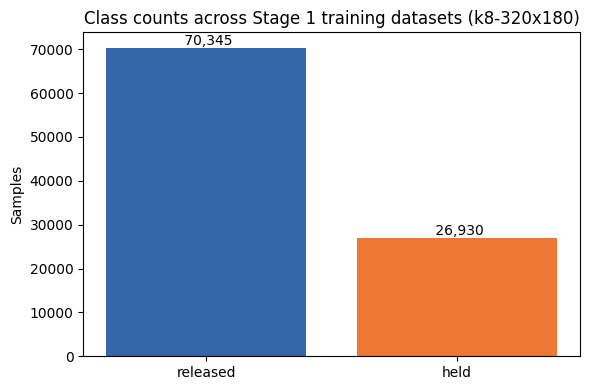

In [7]:
k8_dirs = sorted(
    d for d in DATASETS_DIR.iterdir()
    if d.is_dir() and "k8-320x180" in d.name
)
summaries = []
for d in k8_dirs:
    with (d / "dataset_summary.json").open() as f:
        summaries.append(json.load(f))

total_held = sum(s["held_count"] for s in summaries)
total_released = sum(s["released_count"] for s in summaries)
total_samples = sum(s["sample_count"] for s in summaries)
pos_weight = total_released / total_held

print(f"Stage 1 datasets (k8-320x180): {len(summaries)}")
print(f"Total samples:        {total_samples}")
print(f"Held:                 {total_held}")
print(f"Released:             {total_released}")
print(f"Held ratio:           {total_held / total_samples:.3f}")
print(f"Released/held (pos_weight): {pos_weight:.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(
    ["released", "held"],
    [total_released, total_held],
    color=["#3366AA", "#EE7733"],
)
ax.set_ylabel("Samples")
ax.set_title("Class counts across Stage 1 training datasets (k8-320x180)")
for i, v in enumerate([total_released, total_held]):
    ax.text(i, v, f" {v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 7. A materialized training sample

Sample frame_index=1740, action_held=0


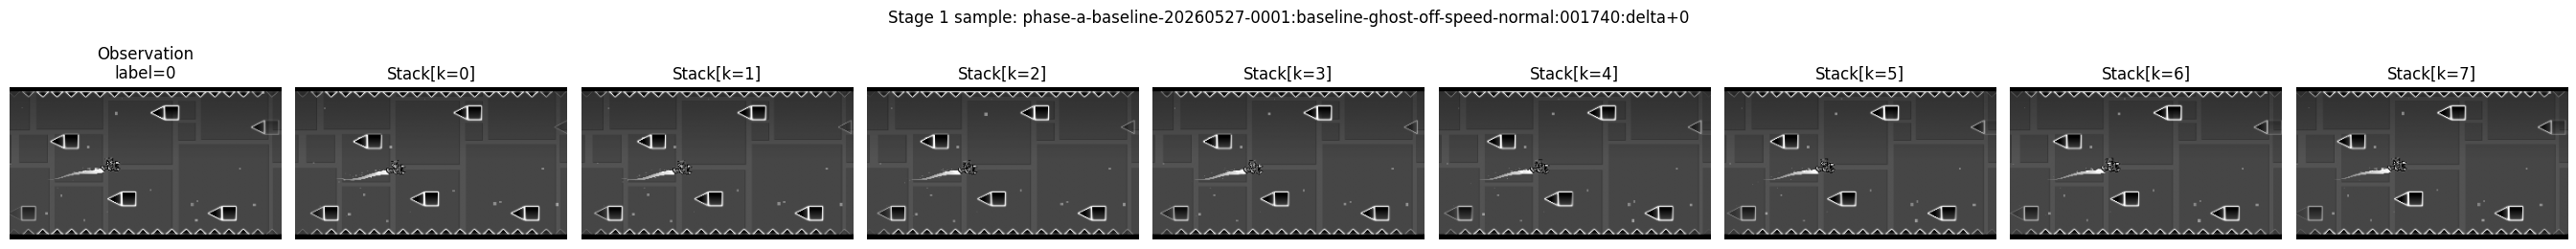

In [8]:
from voxter.preprocessing.stage1_dataset import load_pgm_image

manifest_path = stage1_dir / "stage1_manifest.jsonl"
with manifest_path.open() as f:
    rows = [json.loads(line) for line in f]

# Skip the early menu frames and pick the middle of the run.
mid_row = rows[len(rows) // 2]
print(f"Sample frame_index={mid_row['frame_index']}, action_held={mid_row['action_held']}")

obs_path = stage1_dir / "observations" / Path(mid_row["observation_path"]).name
stack_path = stage1_dir / "stacks" / Path(mid_row["frame_stack_path"]).name

W = dataset_summary["observation_width"]
H = dataset_summary["observation_height"]
K = dataset_summary["frame_stack_length"]

observation = np.frombuffer(obs_path.read_bytes(), dtype=np.uint8).reshape((H, W))
frame_stack = np.frombuffer(stack_path.read_bytes(), dtype=np.uint8).reshape((K, H, W))

fig, axes = plt.subplots(1, K + 1, figsize=(3 * (K + 1), 3))
axes[0].imshow(observation, cmap="gray", vmin=0, vmax=255)
axes[0].set_title(f"Observation\nlabel={mid_row['action_held']}")
axes[0].axis("off")
for k in range(K):
    axes[k + 1].imshow(frame_stack[k], cmap="gray", vmin=0, vmax=255)
    axes[k + 1].set_title(f"Stack[k={k}]")
    axes[k + 1].axis("off")
plt.suptitle(f"Stage 1 sample: {mid_row['sample_id']}")
plt.tight_layout()
plt.show()

## 8. Stage 2 model architecture and why it was chosen

The deployed policy is a Stage 2 recurrent network. Formally, for one step:

$$
\tilde x_t = x_t / 255,
\qquad
u_t = \text{Hardswish}(\text{BN}(\text{Conv}_{1\times1}(\tilde x_t))),
$$

$$
z_t = \text{AvgPool}(\text{MobileNetV3-small}_{\text{features}}(u_t)) \in \mathbb R^{576},
$$

$$
r_t = [z_t, a_{t-1}] \in \mathbb R^{577},
\qquad
h_t = \text{GRU}(h_{t-1}, r_t),
$$

$$
\ell_{\text{held},t} = W_h h_t + b_h,\quad
\ell_{\text{press},t} = W_p h_t + b_p,\quad
\ell_{\text{release},t} = W_r h_t + b_r.
$$

The held-state probability is $p_{\text{held},t}=\sigma(\ell_{\text{held},t})$. The transition heads are used by the runtime decoder but do not change the action space.

**Why MobileNetV3-small + GRU?** Geometry Dash observations are small ($180\times320$) grayscale stacks. A pretrained MobileNetV3-small provides a strong, compact visual prior while keeping inference latency low; at Stage 2 the encoder is frozen, so only the stack adapter, the GRU, and the three heads are trained. The GRU is justified because the game state is partially observed: horizontal velocity, gravity flips, and portal effects are not visible in a single frame, so recurrent memory is needed to maintain a belief state.

## 9. ONNX interface and parameter counts

In [9]:
import onnx

onnx_path = paths["onnx_model"]
model = onnx.load(onnx_path)

print("ONNX model:", onnx_path.relative_to(PROJECT_ROOT))
print("Opset:", [f"{op.domain or ''}:{op.version}" for op in model.opset_import])
print()
print("Inputs:")
for inp in model.graph.input:
    dims = [d.dim_value if d.dim_value else d.dim_param for d in inp.type.tensor_type.shape.dim]
    print(f"  {inp.name}: shape={dims}, elem_type={inp.type.tensor_type.elem_type}")
print()
print("Outputs:")
for out in model.graph.output:
    dims = [d.dim_value if d.dim_value else d.dim_param for d in out.type.tensor_type.shape.dim]
    print(f"  {out.name}: shape={dims}, elem_type={out.type.tensor_type.elem_type}")

total_params = int(sum(np.prod(list(init.dims)) for init in model.graph.initializer))
print()
print(f"Total parameters (from ONNX initializers): {total_params:,}")

# Trainable parts: 1x1 stack adapter + BN + GRU + three heads.
K = dataset_summary["frame_stack_length"]
adapter = K * 3 + 3
bn = 6
gru = 3 * ((577 + 64) * 64 + 2 * 64)
heads = 3 * (64 + 1)
trainable = adapter + bn + gru + heads
print(f"Estimated trainable parameters (adapter + BN + GRU + heads): {trainable:,}")

ONNX model: models/voxter/voxter.onnx
Opset: [':18']

Inputs:
  frame_stack: shape=[1, 8, 180, 320], elem_type=1
  previous_action: shape=[1], elem_type=1
  hidden: shape=[1, 1, 64], elem_type=1

Outputs:
  held_logit: shape=[1], elem_type=1
  press_logit: shape=[1], elem_type=1
  release_logit: shape=[1], elem_type=1
  next_hidden: shape=[1, 1, 64], elem_type=1

Total parameters (from ONNX initializers): 1,044,647
Estimated trainable parameters (adapter + BN + GRU + heads): 123,684


## 10. Training objectives

The three-stage pipeline is:

**Stage 1** (reactive CNN baseline). Per-frame weighted binary cross-entropy:

$$
\mathcal L_{\text{BC}} = -\sum_t \left[w_1 a_t \log p_t + w_0 (1-a_t)\log(1-p_t)\right],
$$

with class weights derived from the empirical held/released counts.

**Stage 2** (sequential behavioral cloning). For a sequence of length $L$,

$$
\mathcal L_2 = \sum_t \omega_t\, \text{BCE}(a_t, \sigma(\ell_{\text{held},t}))
+ \lambda_{\text{aux}}\bigl[\text{BCE}(e^{\text{press}}_t, \sigma(\ell_{\text{press},t})) + \text{BCE}(e^{\text{release}}_t, \sigma(\ell_{\text{release},t}))\bigr],
$$

where $\omega_t$ up-weights timesteps within radius $r$ of a transition and $\lambda_{\text{aux}}$ weights the auxiliary heads.

**Stage 3** (offline policy gradient). Fine-tunes the Stage 2 policy from rollout rows with discounted returns, KL anchoring to the Stage 2 checkpoint, and entropy regularization:

$$
J(\pi) = \mathbb E_\tau\left[\sum_t \gamma^t r_t\right].
$$

The current Stage 3 run did not demonstrate improvement because the available rollouts contain no terminal steps, so no reliable reward signal is available.

## 11. Training configuration

In [10]:
with paths["onnx_metadata"].open() as f:
    export_metadata = json.load(f)

checkpoint = export_metadata["checkpoint_metadata"]
preprocessing = checkpoint["preprocessing"]
training = checkpoint["training"]
model_meta = checkpoint["model"]

print("Training configuration")
print(f"  epochs:                       {training['epochs']}")
print(f"  batch_size:                   {training['batch_size']}")
print(f"  learning_rate:                {training['learning_rate']}")
print(f"  pos_weight (released/held):   {training['pos_weight']:.3f}")
print(f"  threshold:                    {training['threshold']}")
print(f"  transition_weight_multiplier: {training['transition_weight_multiplier']}")
print(f"  transition_window_radius:     {training['transition_window_radius']}")
print(f"  transition_aux_loss_weight:   {training['transition_aux_loss_weight']}")
print()
print("Preprocessing contract")
print(f"  observation:  {preprocessing['observation_width']}x{preprocessing['observation_height']} {preprocessing['observation_dtype']}")
print(f"  frame stack:  K={preprocessing['frame_stack_length']}, layout={preprocessing['frame_stack_layout']}")
print(f"  delta_sys:    {preprocessing['delta_sys']}")
print(f"  sequence:     length={preprocessing['sequence_length']}, stride={preprocessing['stride']}")
print()
print("Model contract")
print(f"  architecture:             {model_meta['architecture']}")
print(f"  hidden_size:              {model_meta['hidden_size']}")
print(f"  freeze_visual_encoder:    {model_meta['freeze_visual_encoder']}")
print(f"  transition_aux_heads:     {model_meta['transition_auxiliary_heads']}")
print()
print("Data split")
print(f"  train datasets:      {len(checkpoint['train_dataset_dirs'])}")
print(f"  validation datasets: {len(checkpoint['validation_dataset_dirs'])}")

Training configuration
  epochs:                       5
  batch_size:                   4
  learning_rate:                0.001
  pos_weight (released/held):   2.612
  threshold:                    0.5
  transition_weight_multiplier: 4.0
  transition_window_radius:     2
  transition_aux_loss_weight:   1.0

Preprocessing contract
  observation:  320x180 uint8
  frame stack:  K=8, layout=khw
  delta_sys:    0
  sequence:     length=32, stride=32

Model contract
  architecture:             voxter-recurrent-vision-policy
  hidden_size:              64
  freeze_visual_encoder:    True
  transition_aux_heads:     True

Data split
  train datasets:      24
  validation datasets: 6


## 12. Runtime budget and empirical evidence

In [11]:
with paths["benchmark"].open() as f:
    benchmark = json.load(f)
with paths["live_summary"].open() as f:
    live = json.load(f)

print("ONNX microbenchmark (model in isolation)")
print(f"  provider:        {benchmark['provider']}")
print(f"  target_hz:       {benchmark['target_hz']}")
print(f"  tick_budget_ms:  {benchmark['tick_budget_ms']:.2f}")
for k in ["mean", "p50", "p95", "p99", "max"]:
    print(f"  latency {k:5s}: {benchmark['latency_ms'][k]:.2f} ms")
print(f"  passed_tick_budget: {benchmark['passed_tick_budget']}")
print()
print("Live end-to-end run")
print(f"  active_frames:     {live['active_frame_count']}")
print(f"  held_frames:       {live['held_frame_count']}")
print(f"  deaths:            {live['death_count']}")
print(f"  terminal_events:   {live['terminal_event_count']}")
print(f"  missed_deadlines:  {live['missed_deadline_count']}")
print(f"  passed_tick_budget: {live['passed_tick_budget']}")
print(f"  survival_duration_s: {live['survival_duration_s']:.2f}")
print()
print("Live per-stage mean latency (ms)")
for stage in ["capture", "preprocess", "inference", "decision", "control"]:
    print(f"  {stage:10s}: {live[stage]['mean_ms']:.3f}")

ONNX microbenchmark (model in isolation)
  provider:        CPUExecutionProvider
  target_hz:       60.0
  tick_budget_ms:  16.67
  latency mean : 4.76 ms
  latency p50  : 4.71 ms
  latency p95  : 5.97 ms
  latency p99  : 6.47 ms
  latency max  : 7.10 ms
  passed_tick_budget: True

Live end-to-end run
  active_frames:     3121
  held_frames:       318
  deaths:            8
  terminal_events:   29
  missed_deadlines:  7
  passed_tick_budget: False
  survival_duration_s: 13.84

Live per-stage mean latency (ms)
  capture   : 7.189
  preprocess: 0.111
  inference : 8.894
  decision  : 9.052
  control   : 0.024


## 13. Qualitative showcase

The clip below shows the exported ONNX policy playing *Stereo Madness*, a standard level that was not part of the training data.

<video src="../assets/showcase.mp4" controls width="640" height="360">
  Your browser does not support the <code>video</code> element.
</video>

## 14. Supported and unsupported claims

**Supported** by the artifacts:

- A binary held-state action space is implemented end-to-end.
- The dataset contract enforces causal alignment, frame stacking, and terminal cleaning.
- A Stage 2 MobileNetV3-small + GRU policy has been trained and exported to ONNX.
- The exported model meets the 60 Hz inference budget in isolation.
- A live control run has been executed and logged.

**Not yet supported:**

- Reliable completion of unseen standard levels or arbitrary custom levels.
- Guaranteed 60 Hz end-to-end compliance under live capture jitter.
- Demonstrated Stage 3 improvement over Stage 2 imitation.
- Robustness to all game modes, icons, or future updates.

The next iteration should certify live deadline compliance, collect rollout episodes with terminal steps, and evaluate on held-out levels with reproducible configuration metadata.